### ***Job Change Prediction***

#### ***Context***

An Ed-Tech company wants to hire data scientists among people who have successfully passed some courses and then signed up for training. The company wants to know which of the people are looking for a job change and will prefer working with them after completion of training because it helps to reduce the cost and time for categorization of candidates. 

Information related to demographics, education, the experience is in hands from candidates sign up and enrollment.

#### ***Data Description***

* `enrollee_id`: Unique ID for the candidate
* `city`: City code
* `city_development` _index: Development index of the city (scaled)
* `gender`: Gender of the candidate
* `relevent_experience`: Relevant experience of the candidate
* `enrolled_university`: Type of University course enrolled if any
* `education_level`: Education level of candidate
* `major_discipline`: Education major discipline of the candidate
* `experience`: Candidate total experience in years
* `company_size`: No of employees in current employer's company
* `company_type`: Type of current employer
* `lastnewjob`: Difference in years between previous job and current job
* `training_hours`: training hours completed
* `target`: 0 – Not looking for a job change, 1 – Looking for a job change


#### *What is City Development Index?*

*The City Development Index was developed for the Second United Nations Conference on Human Settlements (Habitat II) in 1996 and measures the level of development in cities. The Urban Indicators Programme of the United Nations Human Settlements Programme (UN-Habitat) developed the indicator so that they could rank cities of the world according to their level of development and as a display of indicators depicting development. The CDI cuts across the different clusters identified in the Urban Indicator Framework as it is based on five sub-indices namely, infrastructure, waste, health, education, and city product. It is useful as it provides a snap-shot view of how cities are doing concerning the different indices*

### ***Importing Libraries***

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores and split data
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

# To impute missing values
from sklearn.impute import KNNImputer

# To bin continuous data into intervals
from sklearn.preprocessing import KBinsDiscretizer

# To build a logistic regression model
from sklearn.linear_model import LogisticRegression

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To suppress the warnings
import warnings
warnings.filterwarnings("ignore")

### ***Dataset Load and Review***

In [2]:
job = pd.read_csv("data/32_jobs_data.csv")

In [3]:
# Checking the number of rows and columns in the data
job.shape

(19158, 14)

* The dataset has 19158 rows and 14 columns 

In [4]:
# let's create a copy of the data
df = job.copy()

In [5]:
# let's view a random sample of 10 rows from the data
df.sample(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
4635,4554,city_21,0.624,NaN,No relevent experience,Part time course,Masters,STEM,1,5000-9999,Pvt Ltd,1,55,1.0
1951,33013,city_102,0.804,Male,No relevent experience,Full time course,High School,NaN,6,10/49,Early Stage Startup,1,43,0.0
4721,1306,city_73,0.754,Male,Has relevent experience,Part time course,Graduate,STEM,>20,100-500,Pvt Ltd,1,68,1.0
17633,14190,city_21,0.624,Male,No relevent experience,Full time course,Graduate,STEM,4,NaN,NaN,2,50,1.0
1618,14133,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,Arts,9,50-99,Funded Startup,2,22,0.0
16909,980,city_103,0.920,Male,Has relevent experience,Full time course,Graduate,STEM,8,NaN,NGO,2,21,0.0
13598,7839,city_16,0.910,Male,Has relevent experience,no_enrollment,High School,NaN,10,10000+,Pvt Ltd,2,72,0.0
6659,8716,city_103,0.920,Male,Has relevent experience,no_enrollment,Masters,STEM,12,10000+,Pvt Ltd,1,77,0.0
11438,24212,city_145,0.555,NaN,Has relevent experience,no_enrollment,Graduate,STEM,6,50-99,Pvt Ltd,>4,55,1.0
13080,32625,city_28,0.939,Male,Has relevent experience,no_enrollment,Masters,STEM,5,10/49,Pvt Ltd,>4,48,0.0


In [6]:
# let's check the data types of the columns in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

* ***Only 4 variables are numerical rest all are object types.***
* ***8 columns have less than 19158 non-null values i.e. columns have missing values.***

In [7]:
# let's check for duplicate values in the data
df.duplicated().sum()

np.int64(0)

In [8]:
# let's check for missing values in the data
round(df.isnull().sum() / df.isnull().count() * 100, 2) # df.isnull().count() gives the total number non-null values in each column of the dataframe

enrollee_id                0.00
city                       0.00
city_development_index     0.00
gender                    23.53
relevent_experience        0.00
enrolled_university        2.01
education_level            2.40
major_discipline          14.68
experience                 0.34
company_size              30.99
company_type              32.05
last_new_job               2.21
training_hours             0.00
target                     0.00
dtype: float64

- ***Lot of Missing Values, We will impute these values after we split the data into train, validation and test sets.***

In [9]:
# let's view the statistical summary of the numerical columns in the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
enrollee_id,19158.0,16875.358179,9616.292592,1.000,8554.25,16982.500,25169.75,33380.000
city_development_index,19158.0,0.828848,0.123362,0.448,0.74,0.903,0.92,0.949
training_hours,19158.0,65.366896,60.058462,1.000,23.00,47.000,88.00,336.000
target,19158.0,0.249348,0.432647,0.000,0.00,0.000,0.00,1.000


***Observations***
* ***`enrollee_id:` enrollee_id being a unique identifier doesn't add any meaning to the analysis and can be dropped.***
* ***`city_developement_index:` Since the value of the city development index is normalized a 0.82 average value indicates that most of the data we have is from fairly developed cities (metropolitan cities). However, the range of the index is large and varies from 0.448 to 0.949.***
* ***`training_hours:` Training hours have a wide range from 60hrs to 336hrs. On average, an enrollee has 65hrs of training. 755 of the enrollees less than (or equal to) 88hrs of training.***
* ***`target:` 75% of the enrollees in data are not looking for a job and maybe they just signed up to get trained in new technologies***

In [10]:
df.nunique().sort_values(ascending=False)

enrollee_id               19158
training_hours              241
city                        123
city_development_index       93
experience                   22
company_size                  8
major_discipline              6
company_type                  6
last_new_job                  6
education_level               5
gender                        3
enrolled_university           3
relevent_experience           2
target                        2
dtype: int64

In [11]:
# list of all categorical variables
# get all categorical columns in the dataframe
cat_col = df.select_dtypes(include=["object"]).columns.tolist()

# printing the number of occurrences of each unique value in each categorical column
for column in cat_col:
    print(df[column].value_counts(normalize=True))
    print("-" * 50)

city
city_103    0.227320
city_21     0.141038
city_16     0.080019
city_114    0.069736
city_160    0.044107
              ...   
city_129    0.000157
city_111    0.000157
city_121    0.000157
city_140    0.000052
city_171    0.000052
Name: proportion, Length: 123, dtype: float64
--------------------------------------------------
gender
Male      0.902457
Female    0.084505
Other     0.013038
Name: proportion, dtype: float64
--------------------------------------------------
relevent_experience
Has relevent experience    0.719908
No relevent experience     0.280092
Name: proportion, dtype: float64
--------------------------------------------------
enrolled_university
no_enrollment       0.736043
Full time course    0.200139
Part time course    0.063818
Name: proportion, dtype: float64
--------------------------------------------------
education_level
Graduate          0.620280
Masters           0.233234
High School       0.107872
Phd               0.022141
Primary School    0.016472
N

- ***`city` - There are too many cities and doesn’t look meaningful in the current form***
- ***`experience` - there are too many categories, will need to bin it later***

### ***Data Pre-Processing***

In [12]:
# enrollee_id is unique for each candidate and might not add value to modeling
df.drop(["enrollee_id"], axis=1, inplace=True)

***We will do missing value imputation after splitting the data into train, test and validation to avoid data leakage***

### ***Feature Engineering***

In [13]:
df["city"].nunique()

123

***There are 123 unique cities in data, we can reduce the levels by grouping them into 3 major categories:***
  * ***Developed city - with city development index greater than 0.90***
  * ***Developing city - with city development index between 0.74 and 0.90***
  * ***Under-Developed city - with city development index between 0.4 and 0.74***
  
***We will bin the data after splitting into train/test/val to avoid data leakage.*** 

In [14]:
df["city_development_index"].describe()

count    19158.000000
mean         0.828848
std          0.123362
min          0.448000
25%          0.740000
50%          0.903000
75%          0.920000
max          0.949000
Name: city_development_index, dtype: float64

### ***Missing-Value Treatment***

* ***We will use KNN imputer to impute missing values. `KNNImputer`: Each sample's missing values are imputed by looking at the n_neighbors nearest neighbors found in the training set. Default value for n_neighbors=5.***
* ***KNN imputer replaces missing values using the average of k nearest non-missing feature values. Nearest points are found based on euclidean distance.***
* ***We will be converting categorical columns into numeric***

In [15]:
df.isnull().sum().sort_values(ascending=False)

company_type              6140
company_size              5938
gender                    4508
major_discipline          2813
education_level            460
last_new_job               423
enrolled_university        386
experience                  65
city                         0
city_development_index       0
relevent_experience          0
training_hours               0
target                       0
dtype: int64

In [16]:
# defining a list with names of columns that will be used for imputation
reqd_col_for_impute = [
    "gender",
    "enrolled_university",
    "education_level",
    "major_discipline",
    "experience",
    "company_size",
    "company_type",
    "last_new_job",
]

In [17]:
df[reqd_col_for_impute].head()

,gender,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job
0,Male,no_enrollment,Graduate,STEM,>20,NaN,NaN,1
1,Male,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4
2,NaN,Full time course,Graduate,STEM,5,NaN,NaN,never
3,NaN,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never
4,Male,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4


In [18]:
data1 = df.copy()

In [19]:
# we need to pass numerical values for each categorical column for KNN imputation so we will label encode them
gender = {"Male": 0, "Female": 1, "Other": 2}
data1["gender"] = data1["gender"].map(gender)

enrolled_university = {"no_enrollment": 0, "Full time course": 1, "Part time course": 2}
data1["enrolled_university"] = data1["enrolled_university"].map(enrolled_university)

education_level = {
    "Graduate": 0,
    "Masters": 1,
    "High School": 2,
    "Phd": 3,
    "Primary School": 4,
}
data1["education_level"] = data1["education_level"].map(education_level)

major_discipline = {
    "STEM": 0,
    "Business Degree": 1,
    "Arts": 2,
    "Humanities": 3,
    "No Major": 4,
    "Other": 5,
}
data1["major_discipline"] = data1["major_discipline"].map(major_discipline)

experience = {
    "<1": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "10": 10,
    "11": 11,
    "12": 12,
    "13": 13,
    "14": 14,
    "15": 15,
    "16": 16,
    "17": 17,
    "18": 18,
    "19": 19,
    "20": 20,
    ">20": 21,
}
data1["experience"] = data1["experience"].map(experience)

company_type = {
    "Pvt Ltd": 0,
    "Funded Startup": 1,
    "Early Stage Startup": 2,
    "Other": 3,
    "Public Sector": 4,
    "NGO": 5,
}
data1["company_type"] = data1["company_type"].map(company_type)

company_size = {
    "<10": 0,
    "10/49": 1,
    "100-500": 2,
    "1000-4999": 3,
    "10000+": 4,
    "50-99": 5,
    "500-999": 6,
    "5000-9999": 7,
}
data1["company_size"] = data1["company_size"].map(company_size)

last_new_job = {"never": 0, "1": 1, "2": 2, "3": 3, "4": 4, ">4": 5}
data1["last_new_job"] = data1["last_new_job"].map(last_new_job)

In [20]:
data1.head()

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,city_103,0.920,0.0,Has relevent experience,0.0,0.0,0.0,21.0,NaN,NaN,1.0,36,1.0
1,city_40,0.776,0.0,No relevent experience,0.0,0.0,0.0,15.0,5.0,0.0,5.0,47,0.0
2,city_21,0.624,NaN,No relevent experience,1.0,0.0,0.0,5.0,NaN,NaN,0.0,83,0.0
3,city_115,0.789,NaN,No relevent experience,NaN,0.0,1.0,0.0,NaN,0.0,0.0,52,1.0
4,city_162,0.767,0.0,Has relevent experience,0.0,1.0,0.0,21.0,5.0,1.0,4.0,8,0.0


* Values have been encoded.

### ***Data Preparation for Modeling***

In [21]:
X = data1.drop(["target"], axis=1)
y = data1["target"]

#### ***Data Split into Training, Validation and Test set: In 2 steps***
- ***First Split the data into Temp and Test***
- ***Then Split the Temp into Train and Val***

In [22]:
# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

# print the class before splitting to ensure stratification is working correctly
print(y.value_counts(normalize=True))

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

# then we split the temporary set into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp)

print(X_train.shape, X_val.shape, X_test.shape)

print(y_train.value_counts(normalize=True))

target
0.0    0.750652
1.0    0.249348
Name: proportion, dtype: float64
(11494, 12) (3832, 12) (3832, 12)
target
0.0    0.750653
1.0    0.249347
Name: proportion, dtype: float64


***`KBinsDiscretizer()` is helpful in binning the continuous variable.Based on the city development index, we will group the data as under developed city, developing city and developed city. We need to first sort the development index values and create 3 bins so that we can classify the city value as under developed city, developing city and developed city.***

***`KBinsDiscretizer()` has the following parameters :***
* ***`n_bins`:  The number of bins to produce***
* ***`encode`{‘onehot’, ‘onehot-dense’, ‘ordinal’}: Method used to encode the transformed result We will use "ordinal" as it return the bin identifier encoded as an integer value.***
* ***`strategy`{‘uniform’, ‘quantile’, ‘kmeans’}: Strategy used to define the widths of the bins. We will use "quantile" method as we need to sort the data and create bins.***
      
***To avoid data leakage, we will process the data after splitting, fit_transform the method on train set and then transform it to validation and train set.***

In [23]:
# Discretize variable into 3 equal-sized buckets based on quantiles
bins_transform = KBinsDiscretizer(n_bins=3, encode="ordinal", strategy="quantile")

# Fit and transform the train data
X_train["city"] = bins_transform.fit_transform(np.array(X_train["city_development_index"]).reshape(-1, 1))

# .reshape(-1, 1) is a NumPy method that transforms a 1D array into a 2D column vector, and the -1 tells NumPy 
# to figure out the appropriate number of rows automatically based on the data size. This is necessary because the `KBinsDiscretizer` expects a 2D array as input.

# Transform the val data
X_val["city"] = bins_transform.transform(np.array(X_val["city_development_index"]).reshape(-1, 1))

# Transform the test data
X_test["city"] = bins_transform.transform(np.array(X_test["city_development_index"]).reshape(-1, 1))

In [24]:
## Adding labels to the city and map it to the train, val and test set
labels = {0: "Under_Developed", 1: "Developing", 2: "Developed"}
X_train["city"] = X_train["city"].map(labels)
X_val["city"] = X_val["city"].map(labels)
X_test["city"] = X_test["city"].map(labels)

#### ***Imputing Missing Values***

In [25]:
imputer = KNNImputer(n_neighbors=5)

# Fit and transform the train data
X_train[reqd_col_for_impute] = imputer.fit_transform(X_train[reqd_col_for_impute])

# Transform the val data
X_val[reqd_col_for_impute] = imputer.transform(X_val[reqd_col_for_impute])

# Transform the test data
X_test[reqd_col_for_impute] = imputer.transform(X_test[reqd_col_for_impute])

In [26]:
# Checking that no column has missing values in train, validation or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
dtype: int64
------------------------------
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
dtype: int64
------------------------------
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size    

***All missing values have been treated. Let's inverse map the encoded values.***

In [27]:
## Function to inverse the encoding
def inverse_mapping(x, y):
    inv_dict = {v: k for k, v in x.items()}
    X_train[y] = np.round(X_train[y]).map(inv_dict).astype("category")
    X_val[y] = np.round(X_val[y]).map(inv_dict).astype("category")
    X_test[y] = np.round(X_test[y]).map(inv_dict).astype("category")

In [28]:
inverse_mapping(gender, "gender")
inverse_mapping(enrolled_university, "enrolled_university")
inverse_mapping(education_level, "education_level")
inverse_mapping(major_discipline, "major_discipline")
inverse_mapping(experience, "experience")
inverse_mapping(company_size, "company_size")
inverse_mapping(company_type, "company_type")
inverse_mapping(last_new_job, "last_new_job")

***Checking inverse mapped values/categories.***

In [29]:
cols = X_train.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_train[i].value_counts())
    print("*" * 30)

city
Developed          4608
Under_Developed    3685
Developing         3201
Name: count, dtype: int64
******************************
gender
Male      10545
Female      835
Other       114
Name: count, dtype: int64
******************************
relevent_experience
Has relevent experience    8274
No relevent experience     3220
Name: count, dtype: int64
******************************
enrolled_university
no_enrollment       8445
Full time course    2340
Part time course     709
Name: count, dtype: int64
******************************
education_level
Graduate          7060
Masters           2761
High School       1245
Phd                245
Primary School     183
Name: count, dtype: int64
******************************
major_discipline
STEM               9805
Business Degree     706
Humanities          391
Arts                248
Other               220
No Major            124
Name: count, dtype: int64
******************************
experience
>20    1977
4       846
5       838
3       

In [30]:
cols = X_val.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_val[i].value_counts())
    print("*" * 30)

city
Developed          1575
Under_Developed    1211
Developing         1046
Name: count, dtype: int64
******************************
gender
Male      3540
Female     253
Other       39
Name: count, dtype: int64
******************************
relevent_experience
Has relevent experience    2784
No relevent experience     1048
Name: count, dtype: int64
******************************
enrolled_university
no_enrollment       2787
Full time course     800
Part time course     245
Name: count, dtype: int64
******************************
education_level
Graduate          2336
Masters            929
High School        423
Phd                 88
Primary School      56
Name: count, dtype: int64
******************************
major_discipline
STEM               3261
Business Degree     225
Humanities          136
Arts                 93
Other                68
No Major             49
Name: count, dtype: int64
******************************
experience
>20    684
5      306
3      272
4      268
6  

In [31]:
cols = X_test.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_test[i].value_counts())
    print("*" * 30)

city
Developed          1554
Under_Developed    1245
Developing         1033
Name: count, dtype: int64
******************************
gender
Male      3478
Female     316
Other       38
Name: count, dtype: int64
******************************
relevent_experience
Has relevent experience    2734
No relevent experience     1098
Name: count, dtype: int64
******************************
enrolled_university
no_enrollment       2809
Full time course     779
Part time course     244
Name: count, dtype: int64
******************************
education_level
Graduate          2329
Masters            920
High School        423
Phd                 91
Primary School      69
Name: count, dtype: int64
******************************
major_discipline
STEM               3206
Business Degree     229
Humanities          158
Arts                 96
Other                93
No Major             50
Name: count, dtype: int64
******************************
experience
>20    625
4      292
5      290
3      278
6  

#### ***Creating Dummy Variables***

In [32]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
print(X_train.shape, X_val.shape, X_test.shape)

(11494, 56) (3832, 56) (3832, 56)


### ***Model Building***

#### ***Model evaluation criterion:***

#### ***Model can make wrong predictions as:***
- ***Predicting an enrollee is looking for a job change but in reality, the enrollee is not looking for a change - Loss of resources, False Positive***
- ***Predicting an enrollee is not looking for a job change but the enrollee is looking for a job change  - Loss of opportunity, False Negative***

#### ***Which case is more important?***
***Predicting an enrollee is not looking for a job change but the enrollee is looking for a job change i.e. losing on a potential candidate as the candidate will not be targeted by the HR team when he should be targeted. Reduce False Negative, Maximize Recall***

In [33]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [34]:
def confusion_matrix_sklearn(model, predictors, y_actual):
    """
    Generates a labeled confusion matrix heatmap.

    Parameters:
    - model: trained classifier
    - predictors: feature matrix to predict on (can be train, test, or validation)
    - y_actual: true labels corresponding to X
    """
    # Predict labels
    y_predict = model.predict(predictors)

    # Compute confusion matrix
    cm = confusion_matrix(y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index=["Actual - No", "Actual - Yes"],
                             columns=["Predicted - No", "Predicted - Yes"])

    # Annotate with counts and percentages
    group_counts = [f"{value:0.0f}" for value in cm.flatten()]
    group_percentages = [f"{value:.2%}" for value in cm.flatten() / np.sum(cm)]
    labels = [f"{count}\n{percent}" for count, percent in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(cm.shape)

    # Plot heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(df_cm, annot=labels, fmt='', cmap='Blues')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

#### ***Logistic Regression***

In [35]:
lr = LogisticRegression(random_state=1)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


***Let's evaluate the model performance by using KFold and cross_val_score***

- ***`K-Folds cross-validation` provides dataset indices to split data into train/validation sets. Split dataset into k consecutive stratified folds (without shuffling by default). Each fold is then used once as validation while the k - 1 remaining folds form the training set.***

- ***`Stratified K-fold` is a variation of KFold that returns stratified folds. The folds are made by preserving the percentage of samples for each class.***

***`Note` - We will check the cross-validated performance on train set set only for this model (logistic regression with original set) to demonstrate `Stratified K-fold`. Since we have sufficient amount of data to split the data into three sets, we will not used K-fold for any other model, instead we will train the model using train set, assess the performance on validation set and use test set only for the final model.***

In [36]:
scoring = "recall"

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)  # Setting number of splits equal to 5

cv_result_bfr = cross_val_score(estimator=lr, X=X_train, y=y_train, scoring=scoring, cv=kfold)

# print the recall mean and standard deviation for the cross-validated results
print(f"Cross-validated Recall: {cv_result_bfr.mean():.4f} ± {cv_result_bfr.std():.4f}")

Cross-validated Recall: 0.2254 ± 0.0187


In [37]:
# Calculating different metrics on train set
log_reg_model_train_perf = model_performance_classification_sklearn(lr, X_train, y_train)

print("Training performance:")
log_reg_model_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.762485,0.221563,0.559965,0.3175


In [38]:
# Calculating different metrics on validation set
log_reg_model_val_perf = model_performance_classification_sklearn(lr, X_val, y_val)

print("Validation performance:")
log_reg_model_val_perf

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.761743,0.232218,0.553616,0.327192


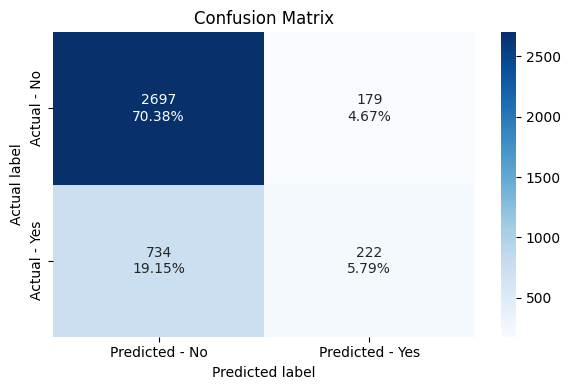

In [39]:
# creating confusion matrix
confusion_matrix_sklearn(lr, X_val, y_val)

* ***Logistic Regression has given a similar performance on training and validation set.***
* ***Recall is very low, we can try oversampling (increase training data) to see if the model performance can be improved.***

#### ***Oversampling train data using SMOTE***

In [40]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)  # Synthetic Minority Over Sampling Technique

X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 2866
Before Oversampling, counts of label 'No': 8628 

After Oversampling, counts of label 'Yes': 8628
After Oversampling, counts of label 'No': 8628 

After Oversampling, the shape of train_X: (17256, 56)
After Oversampling, the shape of train_y: (17256,) 



#### ***Logistic Regression on oversampled data***

In [41]:
log_reg_over = LogisticRegression(random_state=1)

# Training the basic logistic regression model with training set
log_reg_over.fit(X_train_over, y_train_over)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### Let's check the model performance on train and validation set

In [42]:
# Calculating different metrics on train set
log_reg_over_train_perf = model_performance_classification_sklearn(log_reg_over, X_train_over, y_train_over)

print("Training performance:")
log_reg_over_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.800591,0.764024,0.824309,0.793023


In [43]:
# Calculating different metrics on validation set
log_reg_over_val_perf = model_performance_classification_sklearn(log_reg_over, X_val, y_val)

print("Validation performance:")
log_reg_over_val_perf

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.738257,0.459205,0.474595,0.466773


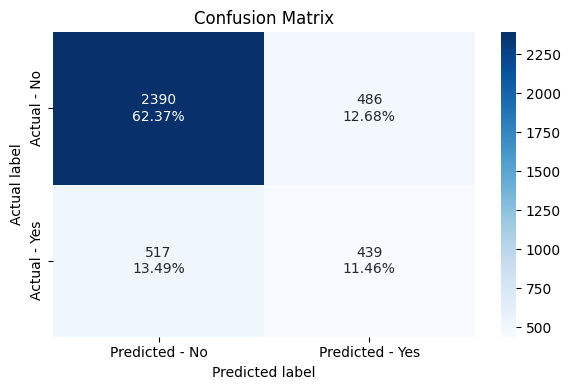

In [44]:
# creating confusion matrix
confusion_matrix_sklearn(log_reg_over, X_val, y_val)

***Performance on the training set improved but the model is not able to replicate the same for the validation set. Model is overfitting.***

***Lets try:***<br>
  ***a) Regularization to see if overfitting can be reduced***<br>
  ***b) Undersampling the train to handle the imbalance between classes and check the model performance.***

#### ***Regularization***

In [45]:
# Choose the type of classifier.
lr_estimator = LogisticRegression(random_state=1, solver="saga") # saga solver supports both L1 and L2 regularization, Default is L2 (Ridge) regularization in Logistic Regression

# Grid of parameters to choose from
parameters = {"C": np.arange(0.1, 1.1, 0.1)} # C is the inverse of regularization strength; smaller values specify stronger regularization.

# Run the grid search
grid_obj = GridSearchCV(lr_estimator, parameters, scoring="recall")
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
lr_estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
lr_estimator.fit(X_train_over, y_train_over)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,np.float64(0.1)
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


In [46]:
# Calculating different metrics on train set
log_reg_reg_train_perf = model_performance_classification_sklearn(lr_estimator, X_train_over, y_train_over)

print("Training performance:")
log_reg_reg_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.737019,0.750464,0.730813,0.740508


In [47]:
# Calculating different metrics on validation set
log_reg_reg_val_perf = model_performance_classification_sklearn(
    lr_estimator, X_val, y_val
)
print("Validation performance:")
log_reg_reg_val_perf

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.708246,0.643305,0.44181,0.52385


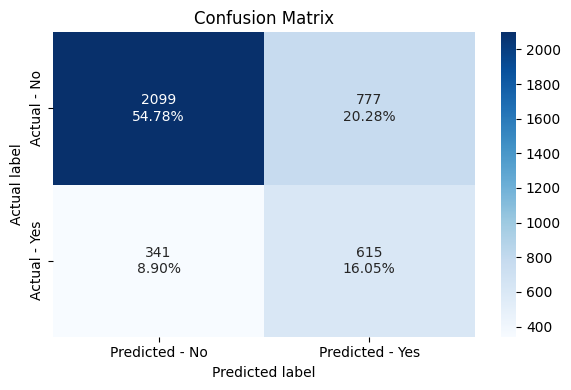

In [48]:
# creating confusion matrix
confusion_matrix_sklearn(lr_estimator, X_val, y_val)

***After regularization, overfitting has reduced to some extent.***

***Let's try undersampling now.***

#### ***Undersampling train data using Random Under Sampler***

In [49]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [50]:
print("Before Undersampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Undersampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Undersampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Undersampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Undersampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Undersampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Undersampling, counts of label 'Yes': 2866
Before Undersampling, counts of label 'No': 8628 

After Undersampling, counts of label 'Yes': 2866
After Undersampling, counts of label 'No': 2866 

After Undersampling, the shape of train_X: (5732, 56)
After Undersampling, the shape of train_y: (5732,) 



#### ***Logistic Regression on undersampled data***

In [51]:
log_reg_under = LogisticRegression(random_state=1)
log_reg_under.fit(X_train_un, y_train_un)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### ***Let's check the model performance on train and validation set***

In [52]:
# Calculating different metrics on train set
log_reg_under_train_perf = model_performance_classification_sklearn(log_reg_under, X_train_un, y_train_un)

print("Training performance:")
log_reg_under_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.699407,0.684578,0.705502,0.694882


In [53]:
# Calculating different metrics on validation set
log_reg_under_val_perf = model_performance_classification_sklearn(log_reg_under, X_val, y_val)

print("Validation performance:")
log_reg_under_val_perf

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.710595,0.686192,0.447782,0.541925


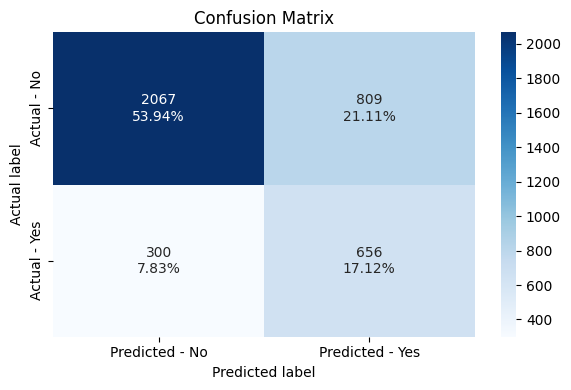

In [54]:
# creating confusion matrix
confusion_matrix_sklearn(log_reg_under, X_val, y_val)

***Model has given similar recall on training and validation set. Model performance has improved using undersampling.***

In [55]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_train_perf.T,
        log_reg_over_train_perf.T,
        log_reg_reg_train_perf.T,
        log_reg_under_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression",
    "Logistic Regression with oversampled data",
    "Regularised Logistic Regression",
    "Logistic Regression with undersampled data",
]
print("Training performance comparison:")
models_train_comp_df.T

Training performance comparison:


,Accuracy,Recall,Precision,F1
Logistic Regression,0.762485,0.221563,0.559965,0.317500
Logistic Regression with oversampled data,0.800591,0.764024,0.824309,0.793023
Regularised Logistic Regression,0.737019,0.750464,0.730813,0.740508
Logistic Regression with undersampled data,0.699407,0.684578,0.705502,0.694882


In [56]:
# Validation performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_val_perf.T,
        log_reg_over_val_perf.T,
        log_reg_reg_val_perf.T,
        log_reg_under_val_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression",
    "Logistic Regression with oversampled data",
    "Regularised Logistic Regression",
    "Logistic Regression with undersampled data",
]
print("Validation performance comparison:")
models_train_comp_df.T

Validation performance comparison:


,Accuracy,Recall,Precision,F1
Logistic Regression,0.761743,0.232218,0.553616,0.327192
Logistic Regression with oversampled data,0.738257,0.459205,0.474595,0.466773
Regularised Logistic Regression,0.708246,0.643305,0.441810,0.523850
Logistic Regression with undersampled data,0.710595,0.686192,0.447782,0.541925


* Logistic regression model on undersampled data has given a better performance with the highest recall on validation data.

### We can see that model tuned using undersampled data is best, let's check the performance of test data

In [57]:
# Calculating different metrics on validation set
log_reg_under_test_perf = model_performance_classification_sklearn(log_reg_under, X_test, y_test)

print("Test performance:")
log_reg_under_test_perf

Test performance:


,Accuracy,Recall,Precision,F1
0,0.700939,0.67644,0.435604,0.529943


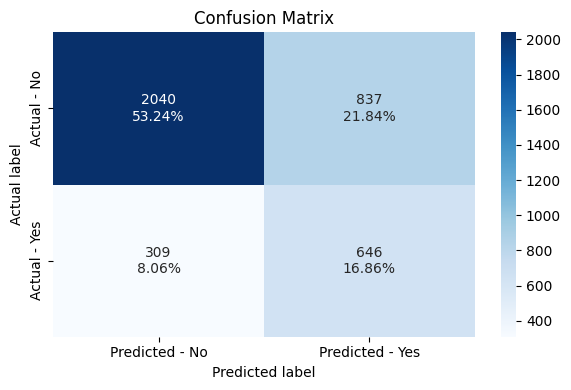

In [58]:
# creating confusion matrix
confusion_matrix_sklearn(log_reg_under, X_test, y_test)

***Model trained with undersampled data has given ~68% recall on the test set.***
